In [1]:
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import torch
from kan import *
import torch.nn as nn
from sympy import symbols
import sympy as sp
from kan.utils import SYMBOLIC_LIB

In [2]:
R_VAL = 50.0 # meters, defined as a global constant for the turbine radius
RHO_VAL = 1.225 # kg/m^3, air density

In [3]:

def calculate_power_curve_vectorized(df, v_col='V', p_col='P', w_col='W', t_col='theta', 
                                     nbins=1000, sigma=3.5, rho=1.225, radius=40, cp_threshold=0.01):
    """
    Calcula curvas de referência e bandas sigma considerando apenas pontos onde
    o coeficiente de potência (Cp) é superior a um limiar mínimo (threshold).
    """
    
    # 1. Cálculo do Cp com proteção contra divisão por zero
    # Se V for muito próximo de zero, o Cp explode para o infinito; tratamos isso aqui.
    v_min_threshold = 0.5 
    v_filtered = df[v_col].where(df[v_col] > v_min_threshold, np.nan)
    
    cp = (2 * df[p_col]) / (rho * np.pi * (radius**2) * (v_filtered**3))
    
    # 2. Aplicar o Limiar (Threshold)
    # Remove valores negativos, zeros e ruído de baixa eficiência
    df_active = df[cp > cp_threshold].copy()
    
    if df_active.empty:
        raise ValueError(f"Nenhum dado com Cp > {cp_threshold} foi encontrado.")

    # 3. Configurações de Bins e Estatísticas
    lower_q = scipy.stats.norm.cdf(-sigma)
    upper_q = scipy.stats.norm.cdf(sigma)
    
    vmin, vmax = df_active[v_col].min(), df_active[v_col].max()
    bins = np.linspace(vmin, vmax, nbins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    df_active['V_bin'] = pd.cut(df_active[v_col], bins=bins, labels=bin_centers, include_lowest=True)

    agg_funcs = ['median', lambda x: x.quantile(lower_q), lambda x: x.quantile(upper_q)]
    
    def get_stats(col):
        # observed=False garante que todos os bins sejam representados no resultado
        agg = df_active.groupby('V_bin', observed=False)[col].agg(agg_funcs)
        agg.columns = ['median', 'lower', 'upper']
        return agg

    # Agregar estatísticas para as três variáveis principais
    p_agg = get_stats(p_col)
    w_agg = get_stats(w_col)
    t_agg = get_stats(t_col)

    def process_curve(series, is_power=False):
        # Reindex para alinhar com os centros dos bins e preencher buracos (ffill)
        curve = series.reindex(bin_centers).ffill()
        curve.iloc[0] = curve.iloc[0] if pd.notna(curve.iloc[0]) else 0
        
        if is_power:
            # Garante que a curva de potência não caia em ventos altos (Saturação)
            v_threshold = 15
            mask = curve.index >= v_threshold
            curve.loc[mask] = curve.loc[mask].cummax()
        return curve.to_numpy()

    return {
        'v_centers': bin_centers,
        'p': (process_curve(p_agg['median'], True), process_curve(p_agg['lower']), process_curve(p_agg['upper'])),
        'w': (process_curve(w_agg['median']), process_curve(w_agg['lower']), process_curve(w_agg['upper'])),
        't': (process_curve(t_agg['median']), process_curve(t_agg['lower']), process_curve(t_agg['upper']))
    }

In [4]:
df = pd.read_csv("/home/nail/Natali/Turbina_Expanded/All-1/turbine_plots_1/R80790_processed.csv")

In [5]:
r =  calculate_power_curve_vectorized(df)

In [6]:
device = 'cpu'

data = np.array([r['v_centers'], r['w'][0], r['t'][0]]).T
#mean_data = data.mean(axis=0)
#std_data = data.std(axis=0)
#data = (data - mean_data)/std_data

inputs = torch.tensor(data).float()

max_P = r['p'][0].max()
p = r['p'][0]/max_P

labels = torch.tensor(p).float().unsqueeze(1)


train_ratio = 0.8
num = inputs.shape[0]
np.random.seed(0)
n_train = max(1, int(num * train_ratio))
train_id = np.random.choice(num, n_train, replace=False)
test_id = list(set(np.arange(num)) - set(train_id))

dataset = {
    'train_input': inputs[train_id].to(device),
    'test_input': inputs[test_id].to(device),
    'train_label': labels[train_id].to(device),
    'test_label': labels[test_id].to(device)
}

In [7]:
model = KAN(width=[3,2,1],seed=0,k=3)

checkpoint directory created: ./model
saving model version 0.0


In [8]:
res = model.fit(dataset,  opt="LBFGS", lr=0.01, steps=1000,loss_fn = nn.MSELoss())

| train_loss: 6.87e-03 | test_loss: 6.17e-03 | reg: 8.23e+00 | : 100%|█| 1000/1000 [00:20<00:00, 49.

saving model version 0.1


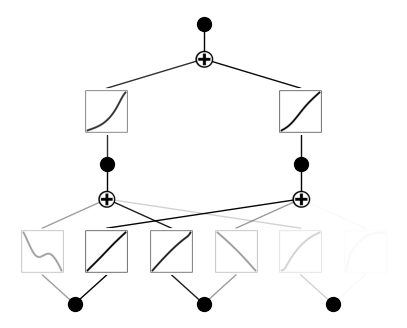

In [9]:
model.plot()
plt.savefig('Rede_KAN_80790.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
model_prediction = model(inputs).detach().numpy()

In [11]:
lambda_real = (r['w'][0] * R_VAL) / r['v_centers']
cp_real = (2 * r['p'][0] ) / (RHO_VAL * np.pi * (R_VAL**2) *  r['v_centers']**3)
cp_predicted = (2 * model_prediction[:,0] * max_P ) / (RHO_VAL * np.pi * (R_VAL**2) *  r['v_centers']**3)

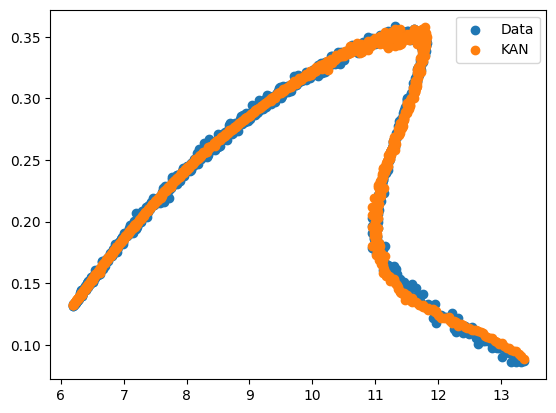

In [12]:
plt.scatter(lambda_real, cp_real,label="Data")
plt.scatter(lambda_real, cp_predicted,label="KAN")
plt.legend()
plt.savefig('data_Kan_80790.png', dpi=300, bbox_inches='tight') # Сохраняем

In [13]:
SYMBOLIC_LIB['sigmoid'] = (
    lambda x: torch.sigmoid(x),              # 1. PyTorch (Forward)
    lambda x: 1 / (1 + sympy.exp(-x)),       # 2. SymPy (Simbólico)
    3,                                       # 3. Complexidade
    lambda x, y_th: ((), torch.sigmoid(x))   # 4. Fitting estável (sem inversa)
)


In [14]:
model.prune()
minha_lib = ['0', 'x', 'x^1.5', 'x^2',  'tanh', 'exp', 'gaussian', 'sigmoid']
model.auto_symbolic(lib=minha_lib,)

saving model version 0.2
fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with x, r2=0.9997710585594177, c=1
fixing (0,1,0) with x, r2=0.9987010359764099, c=1
fixing (0,1,1) with x^2, r2=0.9999905824661255, c=2
fixing (0,2,0) with x, r2=0.9858090877532959, c=1
fixing (0,2,1) with 0, r2=0.0, c=0
fixing (1,0,0) with x^2, r2=0.9988011121749878, c=2
fixing (1,1,0) with x, r2=0.9959644675254822, c=1
saving model version 0.2


In [15]:



# Force o nó da esquerda a ser uma Gaussiana (se for o caso)
model.fix_symbolic(1, 0, 0, 'sigmoid') 

# Force o nó da direita a ser uma Sigmoide ou Tanh (que satura)
model.fix_symbolic(1, 1, 0, 'gaussian') 



Best value at boundary.
r2 is 0.9989683628082275
saving model version 0.3
r2 is 0.9998992681503296
saving model version 0.4


-100000000.0

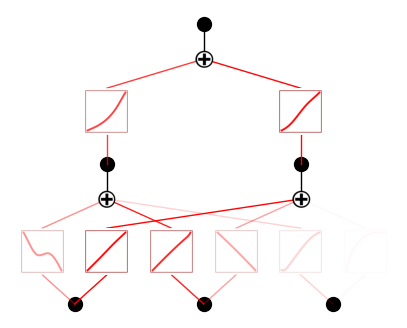

In [16]:
model.plot()
plt.savefig('my_plot_prune_80736.png', dpi=300, bbox_inches='tight') # Сохраняем

In [17]:
#s = [ (s*std_data[i])-mean_data[i] for i, s in enumerate(symbols("V W theta"))]
kan_formula = model.symbolic_formula(var=symbols("V W theta"))[0][0]

In [18]:
print(kan_formula)

0.849352240562439 - 0.893357038497925*exp(-0.982812200945739*(-0.130010276510482*V + exp(0.180639863014221*W) - 0.842863734762321)**2) + 0.926127791404724/(3667.15549312436*exp(-4.28342604123835*W - 4.37224381534506*theta) + 1)


In [19]:
# Ваша формула (предположим, она уже в переменной kan_formula)
# Если формула — это объект, преобразуем её в строку: str(kan_formula)

file_path = "formula_P_80736.tex"

with open(file_path, "w", encoding="utf-8") as f:
    # Добавляем окружение equation для удобства вставки в статью
    f.write("\\begin{equation}\n")
    f.write(str(kan_formula))
    f.write("\n\\end{equation}")

print(f"Формула успешно сохранена в файл: {file_path}")

Формула успешно сохранена в файл: formula_P_80736.tex


In [20]:
import sympy as sp
cp_numerical = sp.lambdify(symbols("V W theta"), kan_formula, 'numpy')


P_formula = cp_numerical(data[:,0], data[:,1], data[:,2])
#P_formula = P_formula * 0.19778233 
cp_formula = (2 * P_formula * max_P ) / (RHO_VAL * np.pi * (R_VAL**2) *  r['v_centers']**3)

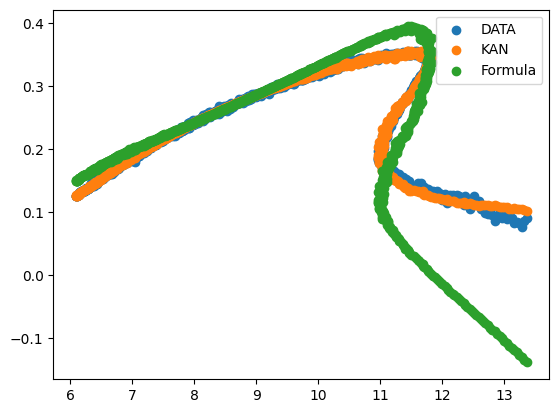

In [21]:
plt.scatter(lambda_real, cp_real,label="DATA")
plt.scatter(lambda_real, cp_predicted,label="KAN")
plt.scatter(lambda_real, cp_formula,label="Formula")
plt.legend()
plt.savefig('Data_KA_formula_80736.png', dpi=300, bbox_inches='tight') # Сохраняем

In [22]:
from IPython.display import display, Math,HTML

from sympy.printing.latex import LatexPrinter

class ScientificLatexPrinter(LatexPrinter):
    """A custom LaTeX printer that formats numbers in scientific notation."""
    def _print_Float(self, expr):
        sci_str = f"{expr:.2e}"
        base, exp = sci_str.split('e')
        exp_val = int(exp)
        if exp_val == 0:
            return base
        else:
            return rf"{base} \times 10^{{{exp_val}}}"
    def _print_Integer(self, expr):
        if abs(expr) > 9999:
            return self._print_Float(float(expr))
        else:
            return str(expr)

sci_printer = ScientificLatexPrinter()


# 1. Define physical symbols and normalization constants
V, W, Theta, Lambda = sp.symbols('V W Theta lambda')
rho, R, P_max = sp.symbols('rho R P_max')


# 3. Step 1: Replace W with the Tip Speed Ratio definition
# W = (lambda * V) / R
kan_with_lambda = kan_formula.subs(W, (Lambda * V) / R)

# 4. Step 2: Convert normalized output back to physical Power (Watts)
power_watts = kan_with_lambda * P_max

# 5. Step 3: Divide by available wind power to get Cp
p_available = (sp.Rational(1, 2)) * rho * sp.pi * (R**2) * (V**3)
cp_formula = power_watts / p_available

# 6. Simplify the expression
# We specifically want to see if V cancels out (as it should in a perfect aerodynamic model)
cp_final = sp.simplify(cp_formula)

print("Formula com Lambda e Física aplicada:")

# Render it
display(Math(sci_printer.doprint(cp_final)))

Formula com Lambda e Física aplicada:


<IPython.core.display.Math object>

In [23]:
# Ваша формула (предположим, она уже в переменной kan_formula)
# Если формула — это объект, преобразуем её в строку: str(kan_formula)

file_path = "formula_Cp_80736_output.tex"

with open(file_path, "w", encoding="utf-8") as f:
    # Добавляем окружение equation для удобства вставки в статью
    f.write("\\begin{equation}\n")
    f.write(str(kan_formula))
    f.write("\n\\end{equation}")

print(f"Формула успешно сохранена в файл: {file_path}")

Формула успешно сохранена в файл: formula_Cp_80736_output.tex
